# Pandas - Merge DataFrames
___
- EG: `pd.merge(df1, df2, on='index')`
- From time to time, you are going to find your Data is incomplete. So we are going to need to Merge it with New Data
- Take for Example the previous Exercise we did where we were Analyzing Data Science Jobs over time, how they were Trending
- What happens now if we want to Combine this Data with Jobs in the Tech Industry specifically those with Developers and see how they Trended with Data Science Jobs
    - Well, we can use **Merge** for this
- We are going to dive into how to Build the Visualization after we first go over a simple Example to understand how to use the Merge Method

- We will need to Create 2 simple Data Frames for this Example
- We have:
    - DataFrame 1 - Named df_jobs
        - Only has job_id, job_title, company_name, job_location
        - And it's only 5 Rows long
    - DataFrame 2 - Named df_companies
        - Only has company_name, industry, company_size
        - And it's only 5 Rows long
- The First Data Frame is similar to what we are looking at from our Dataset, the Second Data Frame is not similar to what's in our Dataset Currently
- Potentially, it's something we may have to source at some point
- This is Company Information. Specifically, Information like the Company Name, the Industry and the Size
- Because we got this Collected for us, we can pretty much Merge this New Data with our source Data Frame
- For this, we can use the Merge Method
    - `pandas.DataFrame.merge()`
    - We will be using the Core Data Frame of our `df_jobs` as the **Left** Data Frame
    - We will be using the new Data Frame of our `df_companies` as the **Right** Data Frame
        - For this we will need to provide a `right` and `left` Argument along with an `on` Argument. There is a `how` Argument, but we will cover that later
        - Right: Object to Merge with, so it's the Data Frame on the Right
        - On: Column or Index Level Names to Join on. In our Case, both Data Frames have this `company_name` Column that is the same across both Data Frames
            - So we can just use that for this Argument
    - In the case, you had different Names for each of the Data Frames, you could specify `left_on` for the **Left** Data Frame and `right_on` for the **Right** Data Frame

In [2]:
import pandas as pd

# DataFrame 1 - Jobs
df_jobs = pd.DataFrame(
    {
        'job_id': [1, 2, 3, 4, 5],
        'job_title': [
            'Data Scientist',
            'Software Engineer ',
            'Product Manager',
            'Marketing Director',
            'HR Manager'
        ],
        'company_name': [
            'Google',
            'Microsoft',
            'Apple',
            'Nike',
            'Starbucks'
        ],
        'job_location': [
            'Mountain View, CA',
            'Redmond, WA',
            'Cupertino, CA',
            'Beaverton, OR',
            'Seattle, WA'
        ]
    },
    index=[0, 1, 2, 3, 4]
)

# DataFrame 2 - Companies
df_companies = pd.DataFrame(
    {
        'company_name': [
            'Google',
            'Microsoft',
            'Apple',
            'Nike',
            'Starbucks'
        ],
        'industry': [
            'Technology',
            'Technology',
            'Technology',
            'Apparel',
            'Food & Beverage'
        ],
        'company_size': [
            '100,000+',
            '100,000+',
            '100,000+',
            '75,000+',
            '346,000+'
        ]
    },
    index=[0, 1, 2, 3, 4]
)

In [ ]:
# Printout of Data Frame 1
df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [ ]:
# Printout of Data Frame 2
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [5]:
# Merge Method on the 2 Example Data Frames
df_jobs.merge(right=df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


- We get back `job_id`, `job_title`, `company_name`, `job_location`, from the Original Data Frame
- And now because it's Merged to that Companies Data Frame, we also get back: `industry` and `company_size`
- Pretty cool! 
- So now, let's move into a more realistic Example that we would encounter out in the real world and one we can Follow along with
    - By using the Data that we have been using up until now

In [8]:
# Imports
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

- In the last Lesson, we made the Data Frame where we Analyzed Jobs in the US (and Canada) specific to different Job Titles and how the Counts of those different Job Titles Trend over the different Months of the Year, specifically in 2023
- We are going to be using that Data Frame from the Last Lesson!
- But with it, it's somewhat Limited with the Fact that we only have Data Science Job Postings
- This doesn't necessarily include **ALL** Tech Job Postings and a commonly Associated Field to Data Science is Software Development
- So there's a lot of Jobs in Software Development that we maybe want to Compare these different Jobs to
    - Luckily, we have a similar Data Set that we can use to Compare to!
    - In here, we have the `job_posted_month` Chronologically Sorted as the Index, along with 4 different Types of Job Titles and their Accossiated Posting Counts divided into the specific Month
        - Job Titles are: **Front-End Developer**, **Back-End Developer**, **Full-Stack Developer** and **UI/UX Designer**
    - Because we have this Data, we can use the **Merge** Method in order to Merge it with our Original Data Frame
    - This Data is Publicly Available so we don't need to Re-Create it, we just need to Import it in
    - So let's do that! We will need to use the Read CSV Function of Pandas
        - `pd.readcsv("")`
        - Inside of here, we then Provide the Link of the Website we need to connect to. **NOTE**: https needs to be Provided so it knows it's a Website it's trying to Connect to

In [11]:
# Re-Creating the Data Frame that we Created Last Lesson

# Create a New Data Frame and Filter the Country. Adding copy at the end so it's completely Unique (Won't Alter the Original)
df_US = df[df['job_country'] == "United States"].copy()

# Creating a New Column and Extrating out the Month Name from the job_posted_date
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

# Creating a Pivot Table on the Data Frame to Group By Months, Sort by Job Titles and Aggregate by the Count
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

# Re-setting the Index
df_US_pivot.reset_index(inplace=True)

# Creating a New Column to get the Month Number Value
df_US_pivot['month_number'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month

# Sorting the Values by the Month Number
df_US_pivot.sort_values('month_number', inplace=True)

# Setting the Index of the Data Frame to the now Chronologically Sorted Month String Value
df_US_pivot.set_index('job_posted_month', inplace=True)

# Dropping the month_number Column
df_US_pivot.drop(columns='month_number', inplace=True)

In [12]:
# Printing out the Data Frame Created from the last Lesson
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [14]:
# Using the Read CSV Function of Pandas to Pull in the Data and Display it as a Data Frame. Using index_col Argument to Set the Index correctly on Import
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')

# Printing it out so we can see it Imported correctly
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


- After Importing it in, we can see it has the `job_posted_month` and all the different Jobs
- Right now it has an **Index** in here, whereas if we look at the Original Data Frame, the `job_posted_month` is the actual **Index**
- So we will need to fix that
    - We can fix it in the actual Import of the Data which is handy and way faster and cleaner then Re-setting it
    - All we need to do is specify `index_col='job_posted_month'` upon Import and bingo bango, we are good
    - Looking at it, we can see the `job_posted_month` has been Shifted to the **Index**
- Now it has everything we need in it!
- Now let's get to Merging these two DataFrames!
    - Using the Data Frame: `df_US_pivot`
    - We Run the Merge Method on this: `.merge()`
    - Specifying the Right one: `df_US_software_pivot`
    - For both of these, we are using that Index of `job_posted_month`: `on="job_posted_month"`

In [20]:
# Running the Merge Method on the 2 Data Frames to combine them on the Index of job_posted_month
df_US_merged = df_US_pivot.merge(df_US_software_pivot, on="job_posted_month")

df_US_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


- We can see now that we've Combined all of these and now we have all of the Data Science Jobs but also our Software Developer Jobs as well
- Going back to that Merge Method...
    - We Glossed over the `how` Parameter and how it's Defaulted to `inner`
    - There's a host of different options available to use
        - `left`, `right`, `outer`, `inner` and `cross`
        - These are all Join Keywords and that's all this is
        - This Merge Method in Python is the Equivelent to Joins in SQL and Merging in Power Query
    - For the time being, we are going to leave this `how` Parameter as `inner` (or Default) as it's the most common Method to actually Join DataFrames and we are not going to really touch it
    - But on occasion, there are times when `right` Joins come into play, which is another commonly done one as well so it's important to know the different between `inner` and `right`
- Getting back to the Task at hand!
    - We want to now Plot, the Top 5 Jobs based on Count of Jobs in the Year and see how they Trend over time

### TODO List
___
- Create a List of the Top 5 Jobs
    - Using `df_US_merged`, we are going to do a `sum()` on it
    - Can't do a `.value_counts()` because there is no name associated to the Job Titles Column Row, so we can't tell it what to Count. It won't know where to look
    - Reason why we need to do `sum()` here. So whenever we Sum them, it's going through and Suming those Columns, convienient we put it in a Pivot Table already
    - And we get the different Total Counts of all the different Job Postings
    - We then Organize it and Order by Descending Order. To do this, we use `.sort_values(ascending=False)`
    - Now we have it Sorting in Descending order, now we only want the Top 5 Results so we Run `head()` method to get that (Default is 5)
    - Then we want only the **Index** because we have no need for the Values, only the Name, so we use `.index` to get that
    - Then we want those Values in a List, so we Convert them to a List by using `.to_list()` so that it gives us the Titles back in a List
    - **PRO TIP**: 
    - When we have something that's getting really long with loads of Methods invoked, it starts to get difficult to read
    - What we can do, is enclose it in Parenthesis **()** and Indent it out so make it easier to read and see what's going on
    - Doing this makes it Run without Issue and also makes it easier to follow and go through step by step
- Filter our Data Frame down to only include those
- Plot the Final Results

In [33]:
# Get the Top 5 Jobs from our Data Frame
top_5 = (
    df_US_merged
    .sum()
    .sort_values(ascending=False)
    .head()
    .index # Get the Index of the Top 5
    .to_list()
)

# Printing out our Result
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

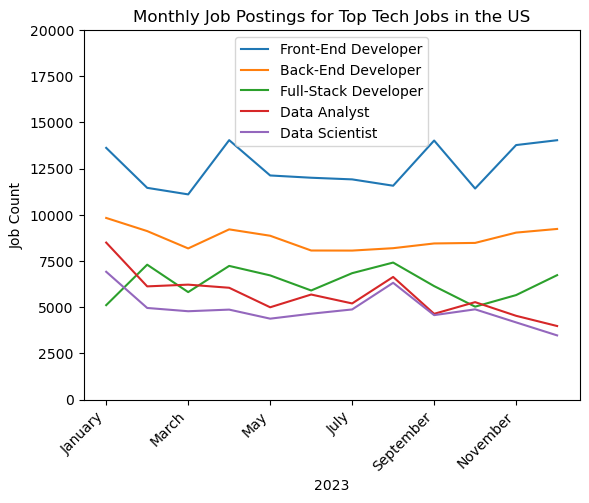

In [43]:
# Plotting a Line Graph of the Merged Data Frames Filtered by the Top 5 Jobs
df_US_merged[top_5].plot(kind='line')

# Cleaning it up to make it presentable
plt.title('Monthly Job Postings for Top Tech Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Closing Remarks and Insights Learned
___
- This is now more Readable and it's something we can actually use
- With this, we can see certain Trends...
    - Front-End and Back-End Developers have a lot higher Job Counts and this is pretty representistic because Developer Jobs are usually more frequent than Data Science Jobs
    - From there, Full-Stack Developer are more in line with Data Analyst and Data Scientist. None of them have outrageous Values throughout the Year
    - They look like they are pretty steady